# Famma French Model
Using data form 01-01-2020 to 31-12-2024 (5 Years)  

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "TSLA", "LLY", "JPM",
    "V", "UNH", "XOM", "MA", "AVGO", "JNJ", "WMT", "PG", "HD", "MRK",
    "COST", "ADBE", "ORCL", "PEP", "CVX", "ABBV", "BAC", "CRM", "TMO", "NFLX",
    "KO", "ACN", "ABT", "LIN", "INTC", "NKE", "MCD", "AMD", "DHR", "WFC",
    "TXN", "AMGN", "NEE", "UPS", "QCOM", "PM", "IBM", "MS", "BMY", "LOW"
]
startdate = datetime(2020,1,2) #choosing the start of the month
enddate = datetime(2024,12,31)
data = yf.download(tickers, start = startdate, end = enddate, auto_adjust=False)['Adj Close']
data.dropna(inplace=True) # Dropping any row with NA data
data = data.pct_change().dropna()
#data is percent change per day (in percentage itself)

ffdata = pd.read_csv('F-F_Research_Data_Factors_daily.csv')

#  keeping only required data
ffdata = ffdata[ffdata['Date'] > 20200102]
ffdata = ffdata[ffdata['Date'] < 20241231]
ffdata['Date'] = pd.to_datetime(ffdata['Date'], format='%Y%m%d')
ffdata.set_index('Date', inplace=True)

#subtract Risk free Rate
for stock in tickers:
    data[stock] -= ffdata['RF']

import statsmodels.api as sm 

def regression (tickers):
    betas = []
    for stock in tickers:
        X = sm.add_constant(ffdata[['Mkt-RF','SMB','HML']])
        y =data[stock]
        model = sm.OLS(y,X).fit()
        betas.append(model.params.values)
    betas_df = pd.DataFrame(betas, columns=['Alpha_factor','Mkt-RF','SMB','HML'],index = tickers)
    return betas_df,model

betas, model= regression(tickers)
risk_free_daily = ffdata.pop('RF')

ffdata_coeff = ffdata.copy()
ffdata_coeff['Alpha_factor'] = 1
ffdata_coeff = ffdata_coeff.reindex(columns=['Alpha_factor', 'Mkt-RF', 'SMB', 'HML'])


reconstructed_returns = ffdata_coeff @ betas.T
for stock in tickers:
    reconstructed_returns[stock] += returns_daily.loc[reconstructed_returns.index]




[**********************96%*********************  ]  48 of 50 completedFailed to get ticker 'WFC' reason: Failed to perform, curl: (28) Connection timed out after 10006 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  50 of 50 completed


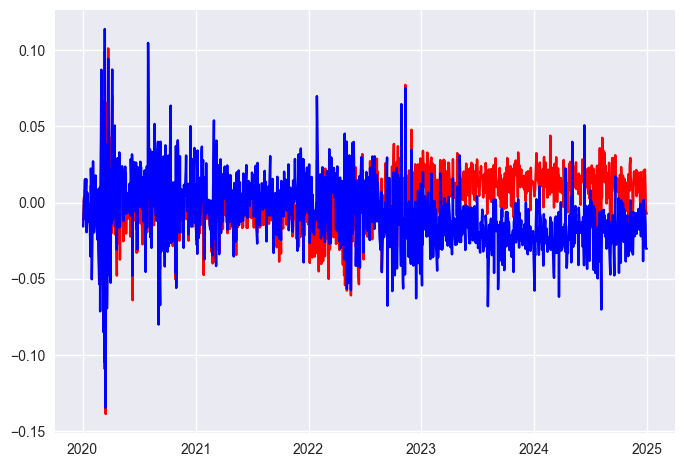

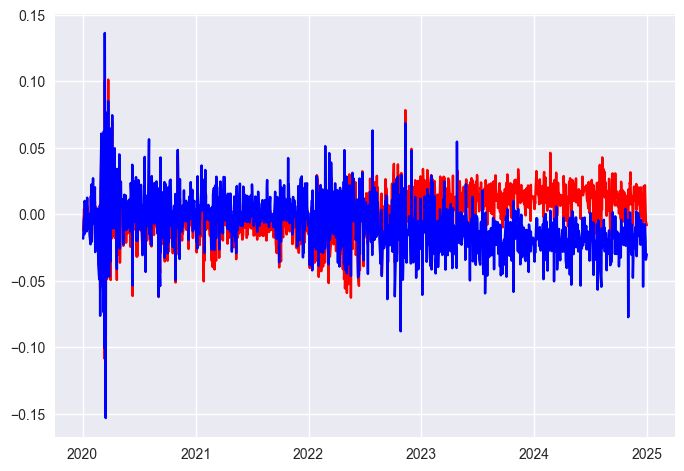

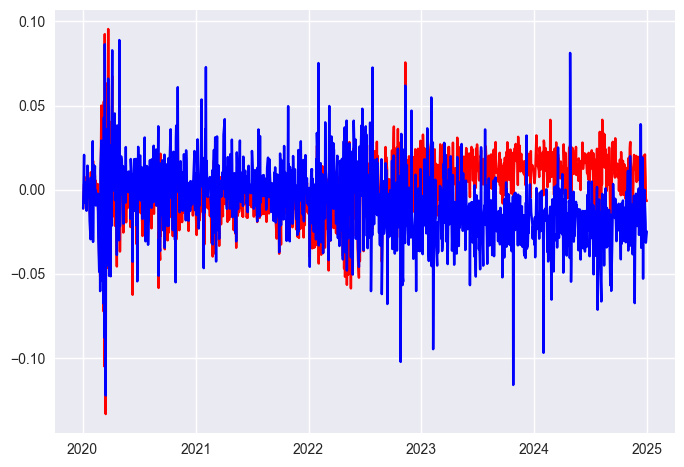

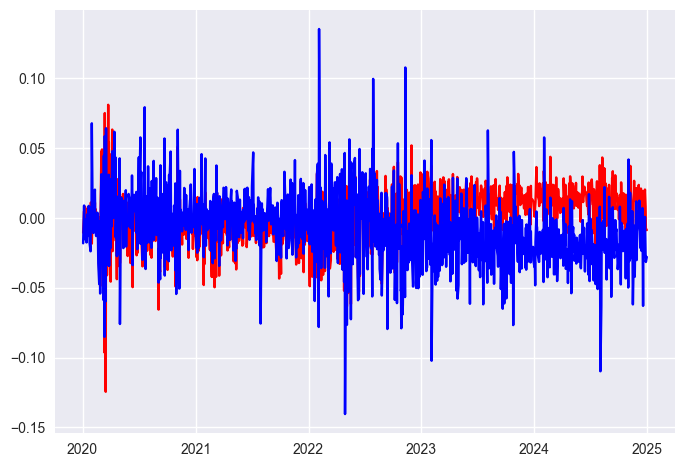

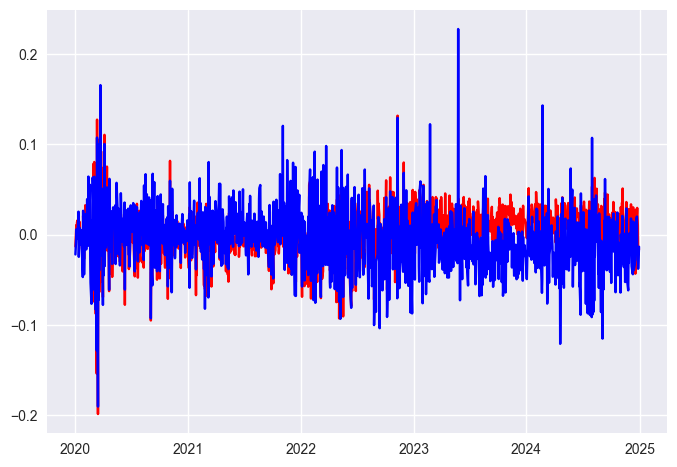

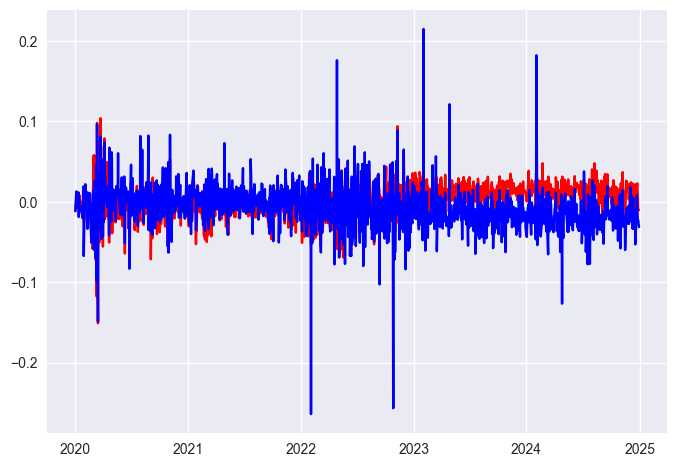

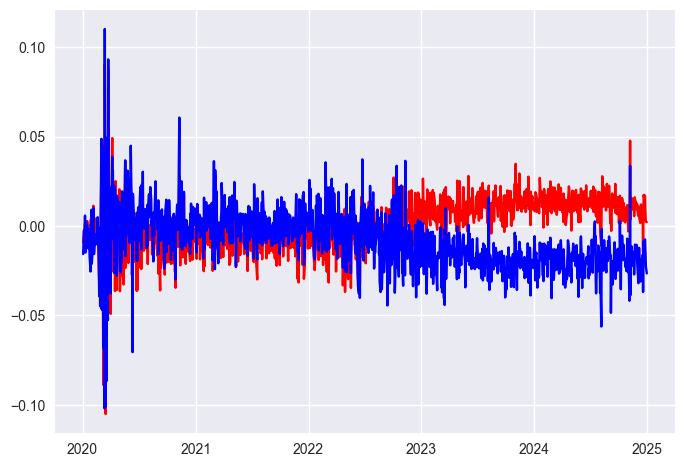

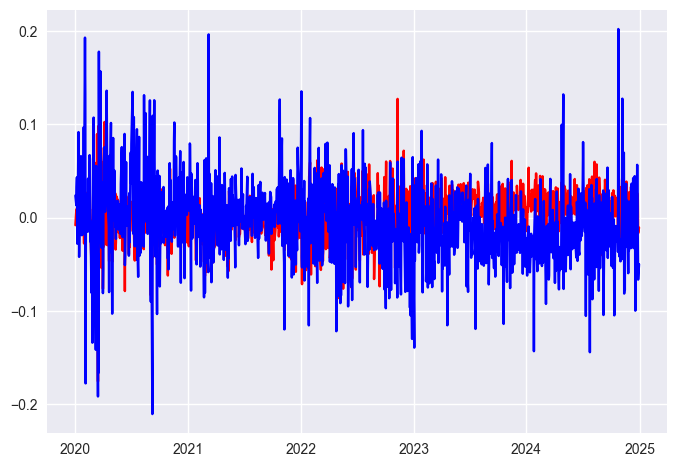

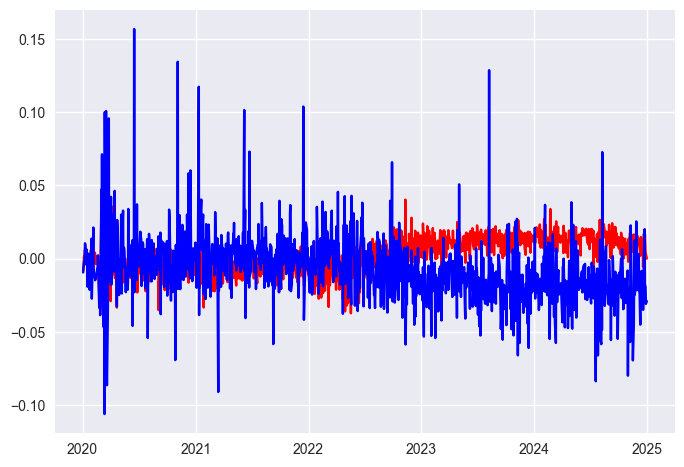

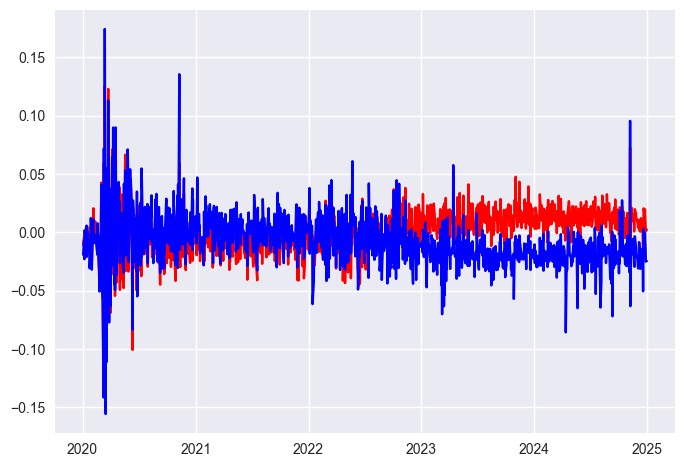

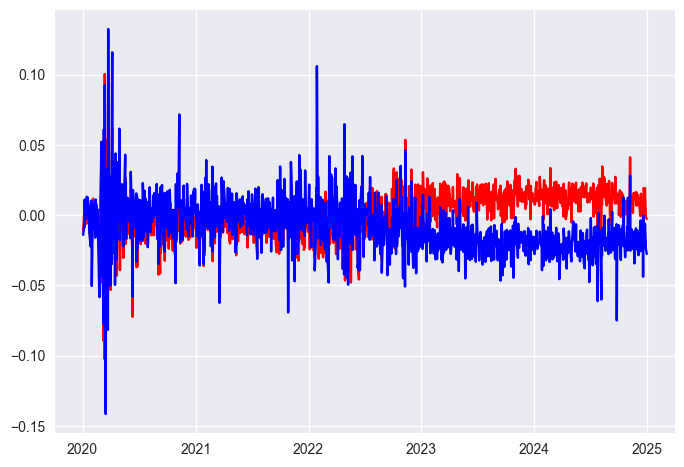

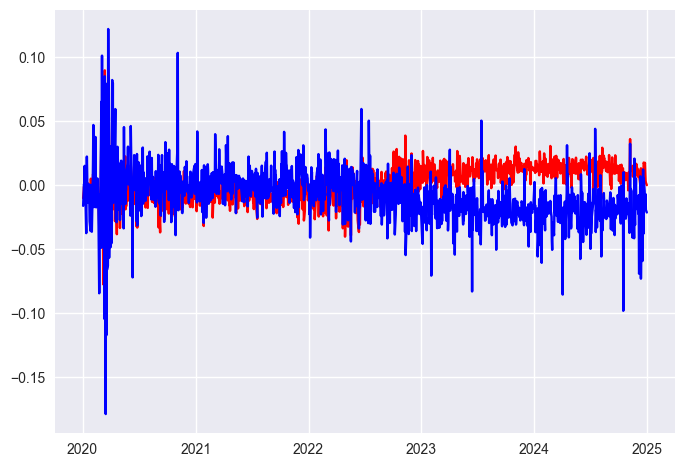

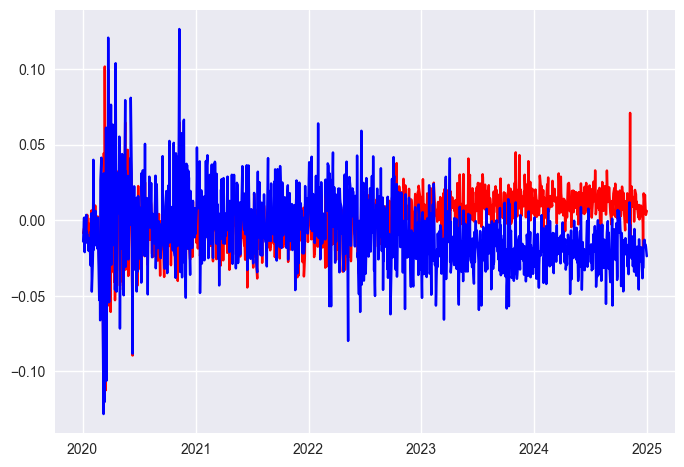

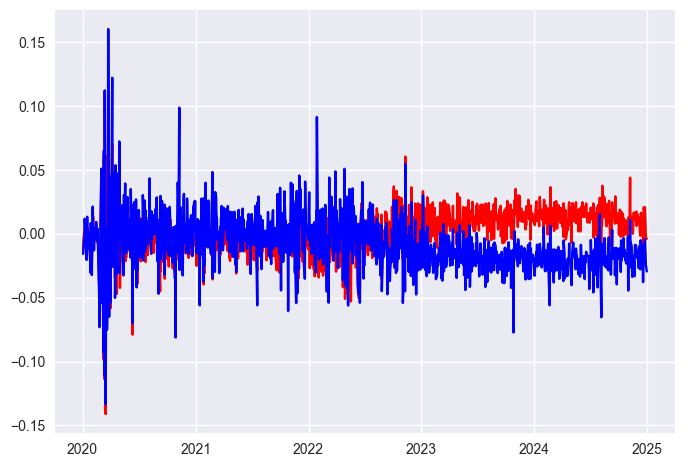

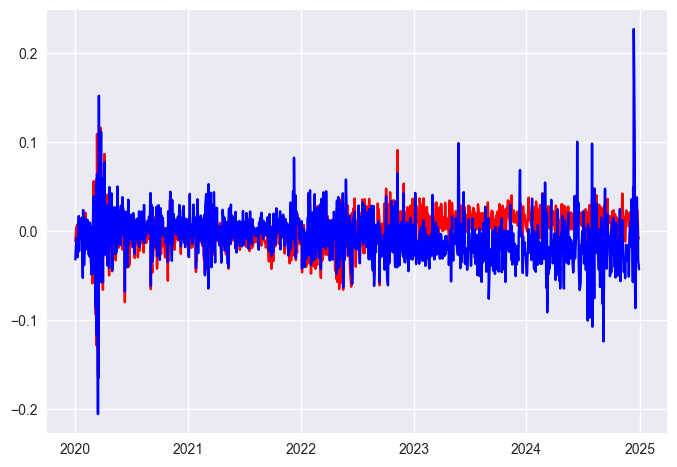

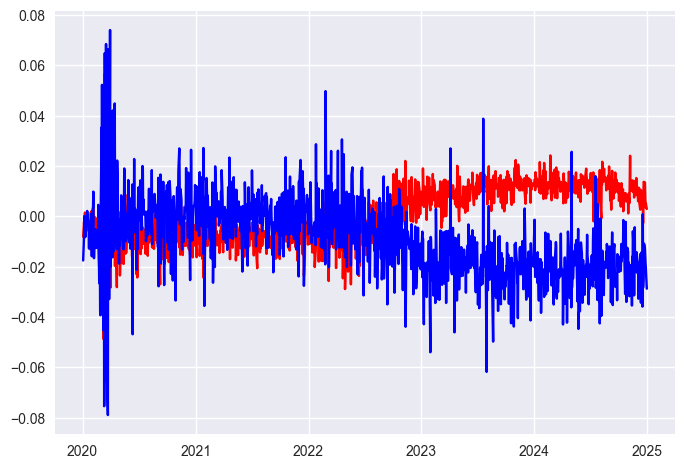

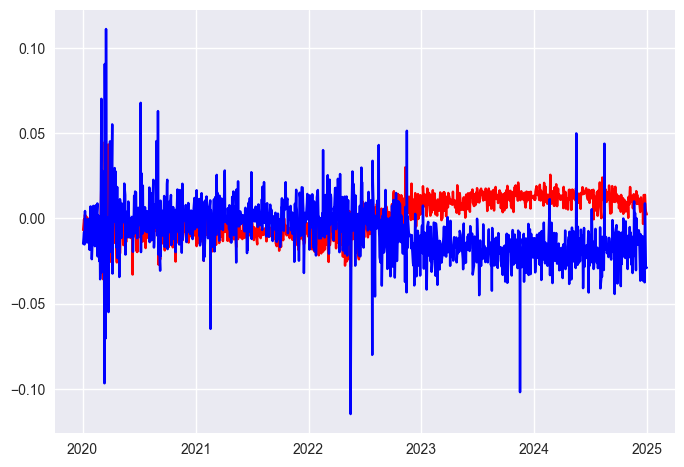

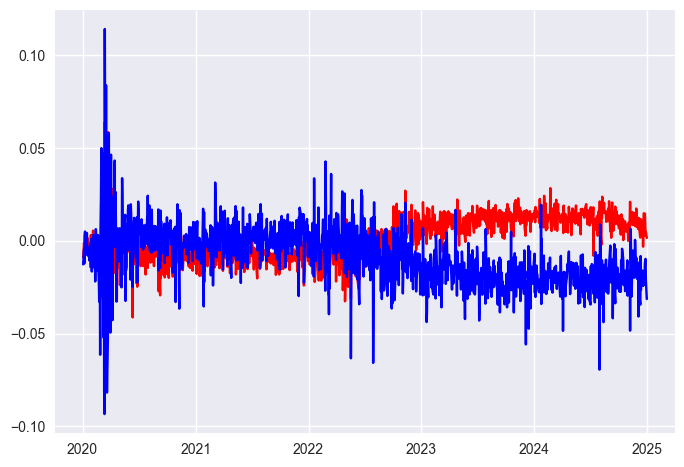

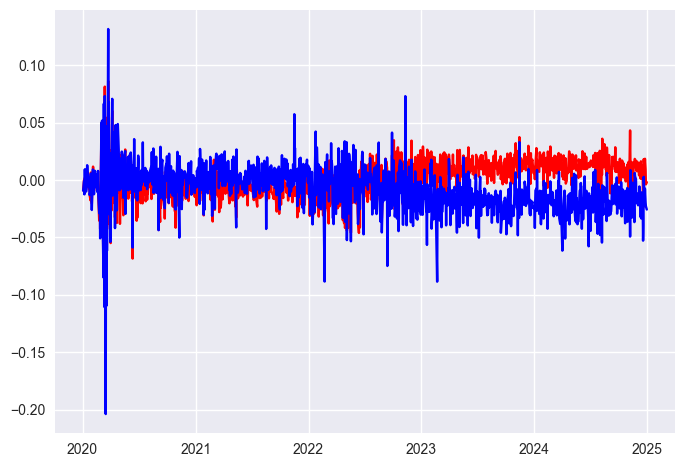

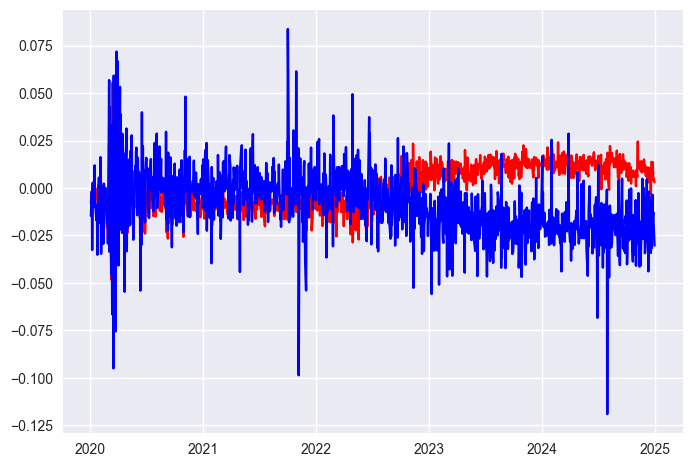

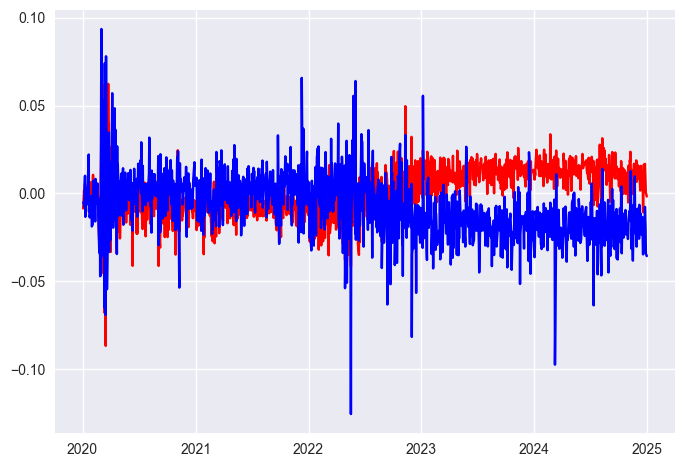

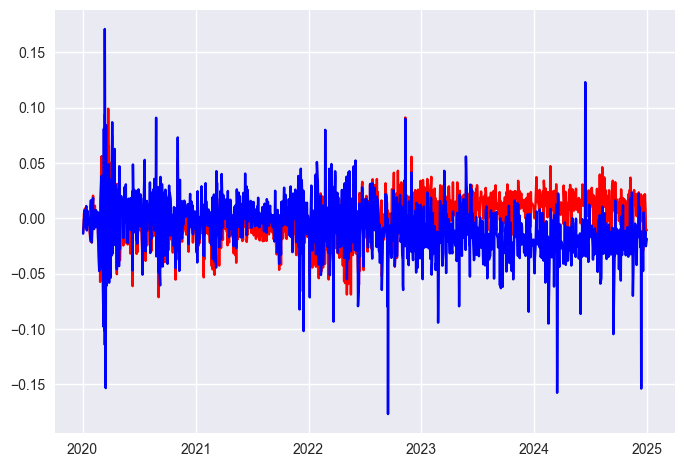

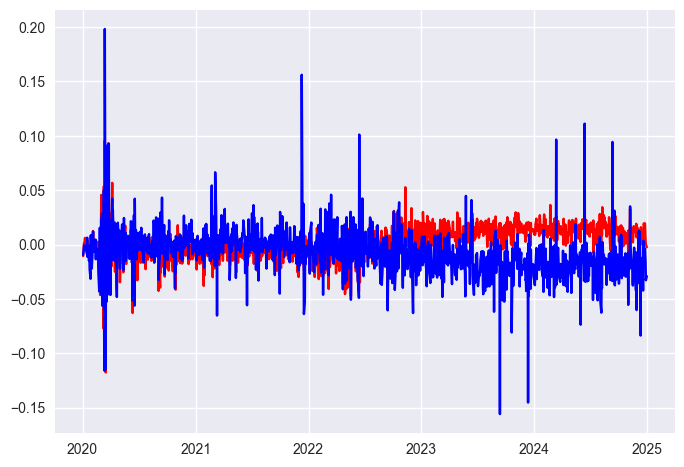

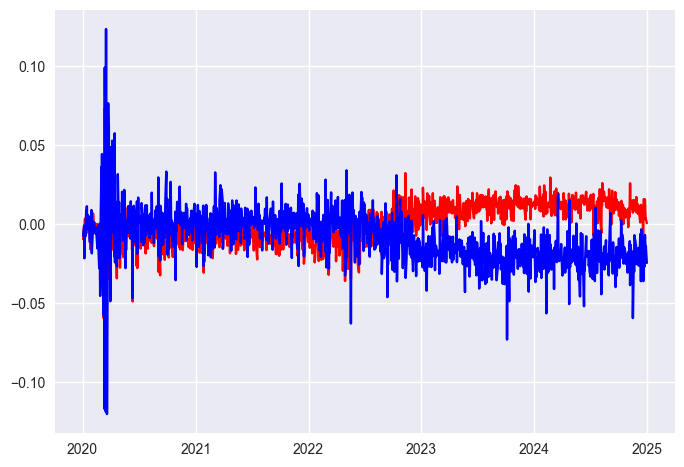

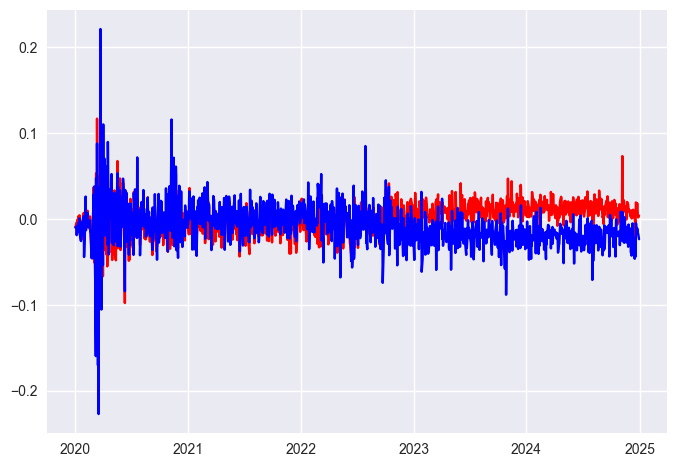

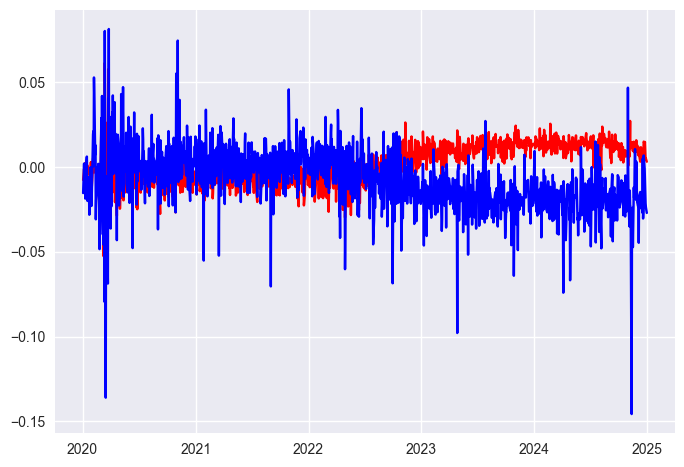

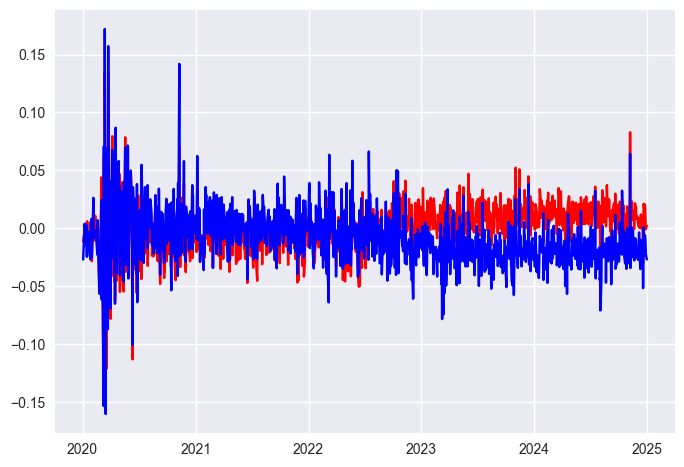

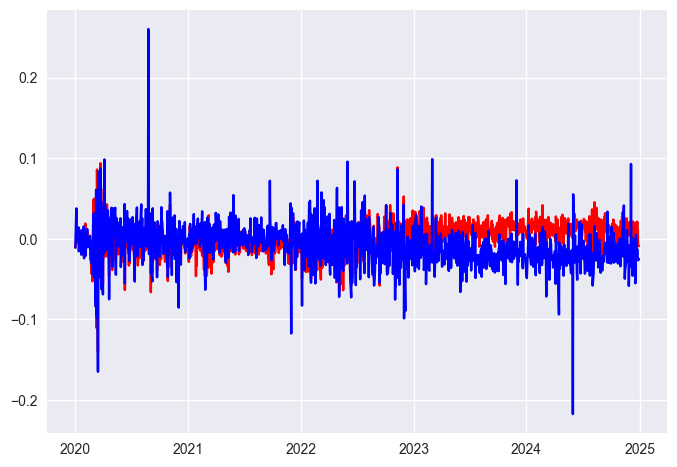

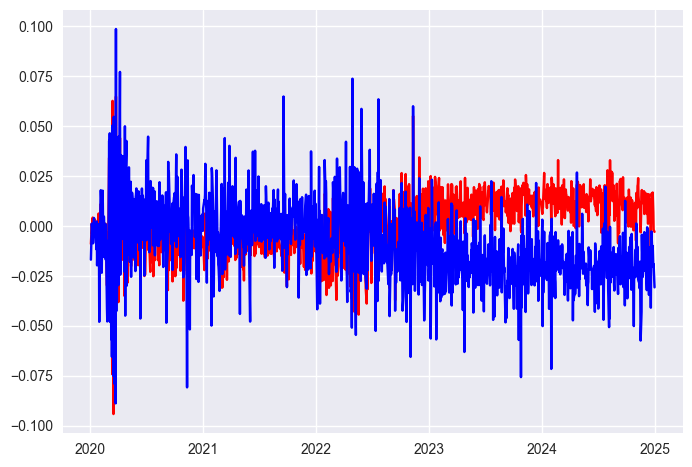

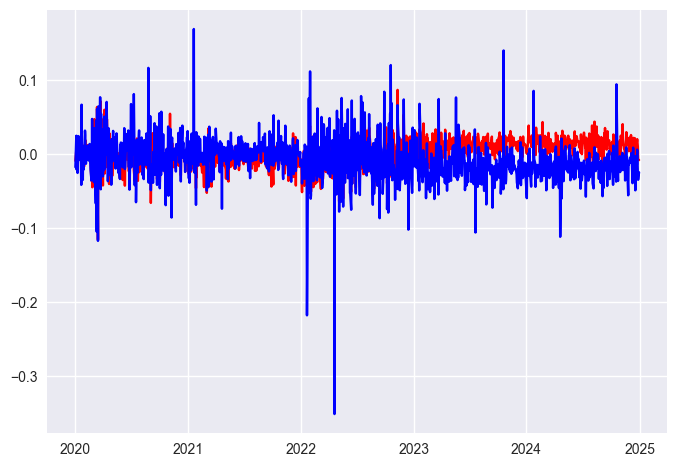

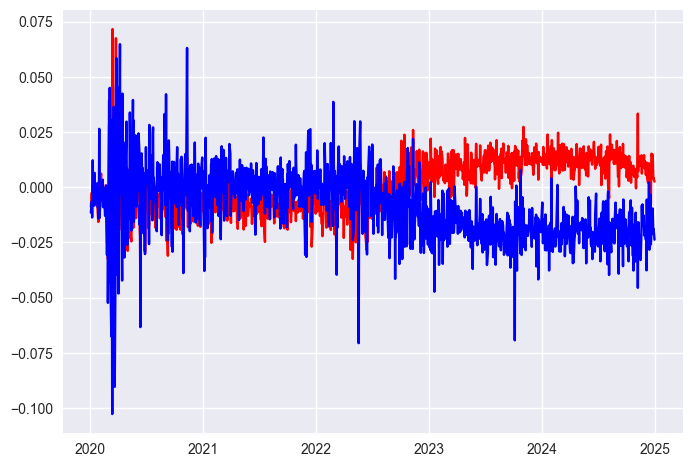

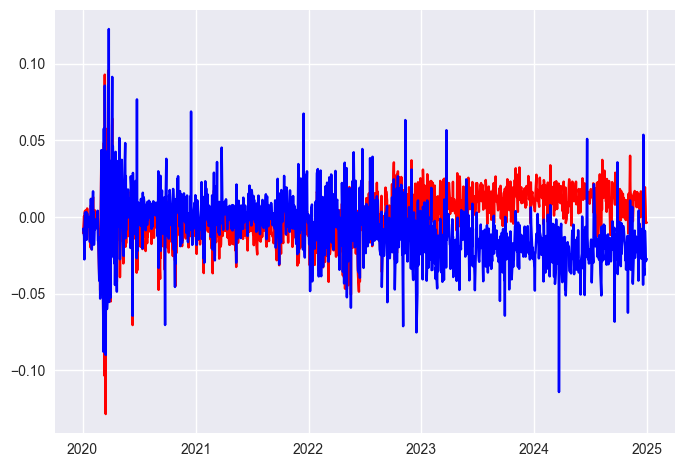

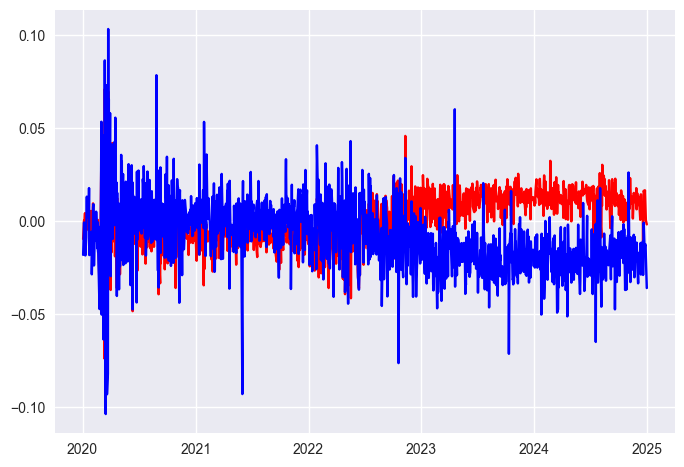

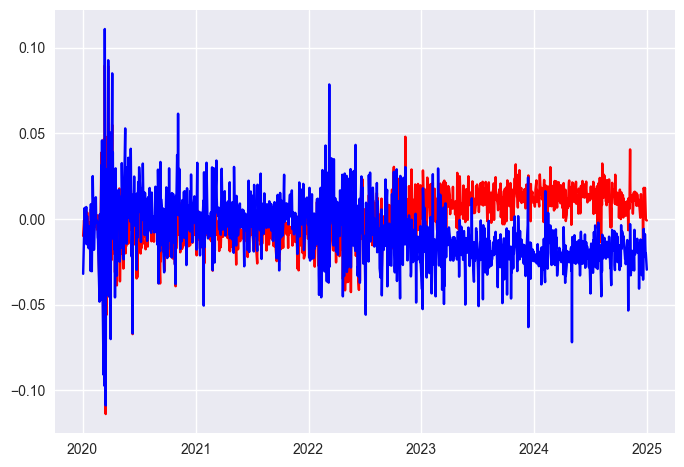

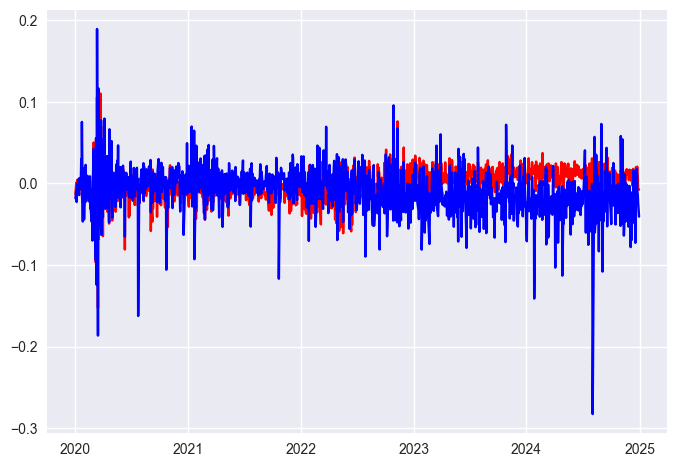

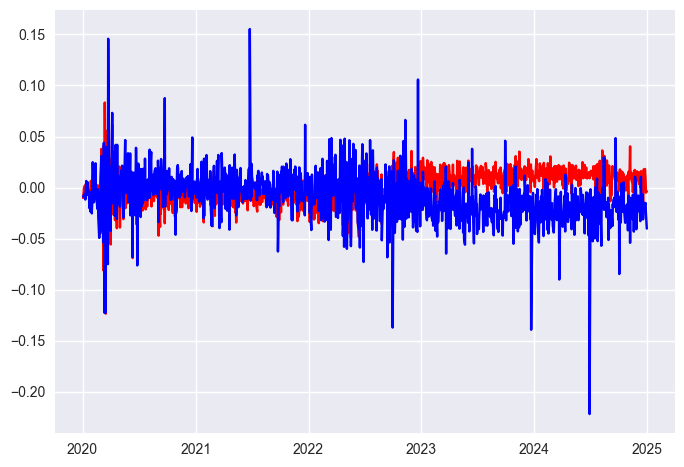

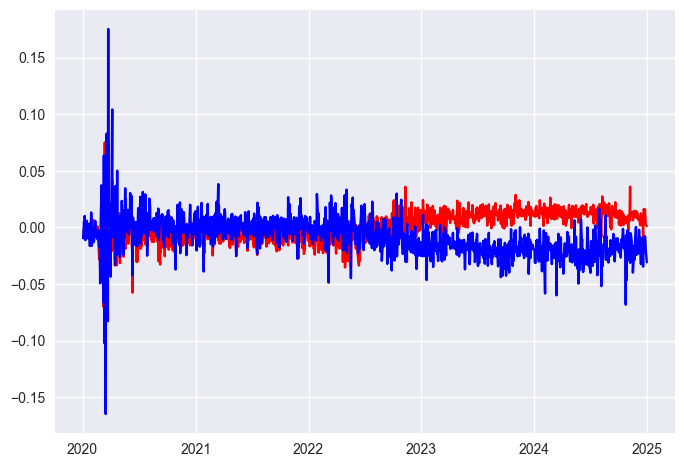

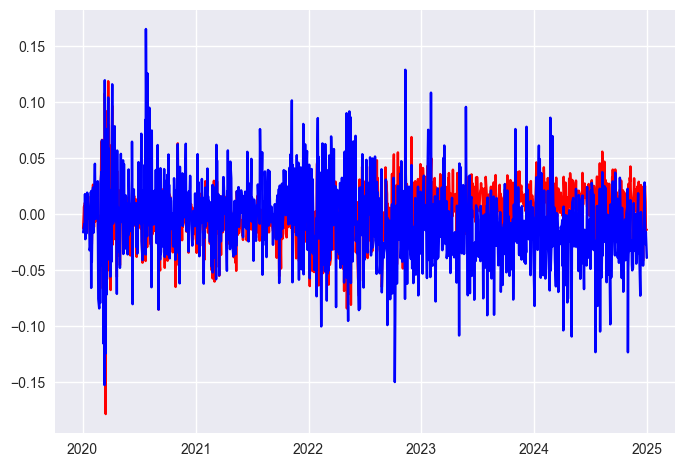

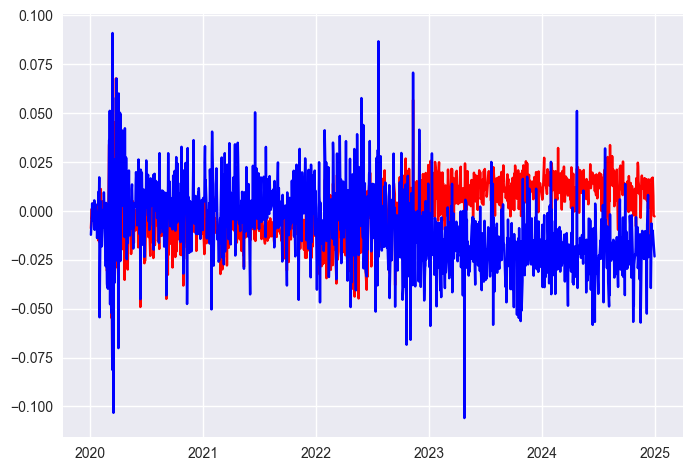

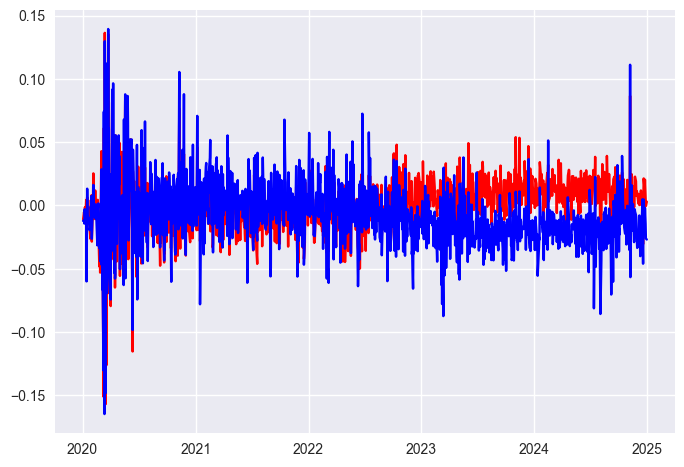

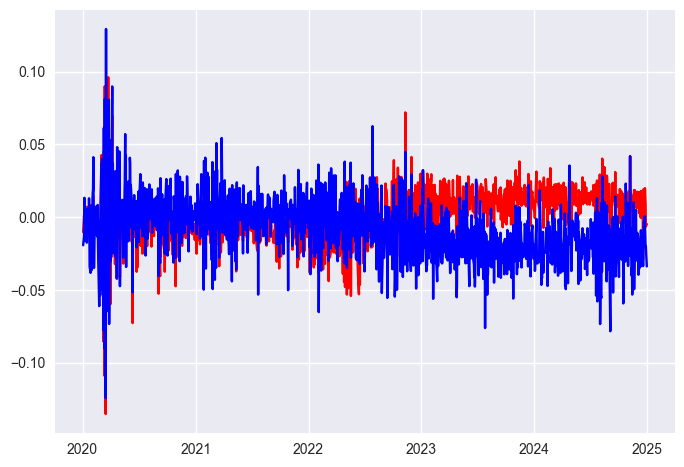

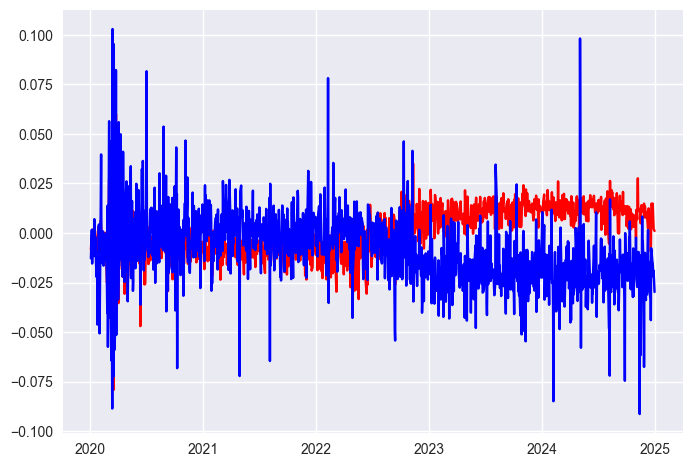

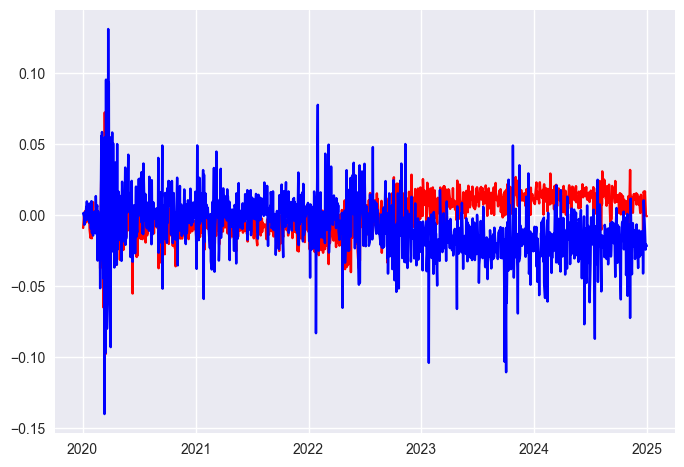

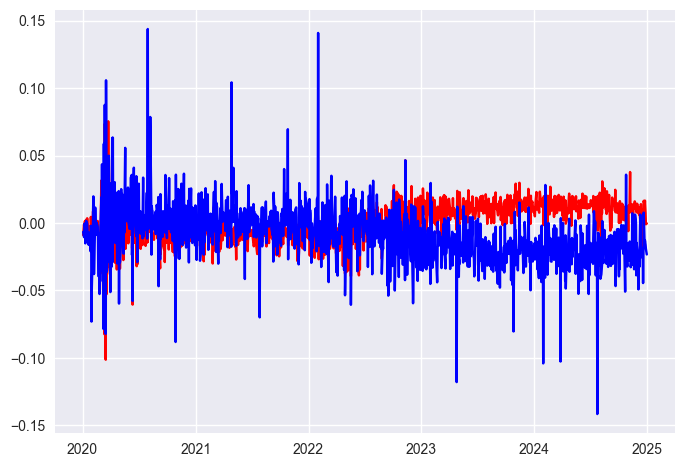

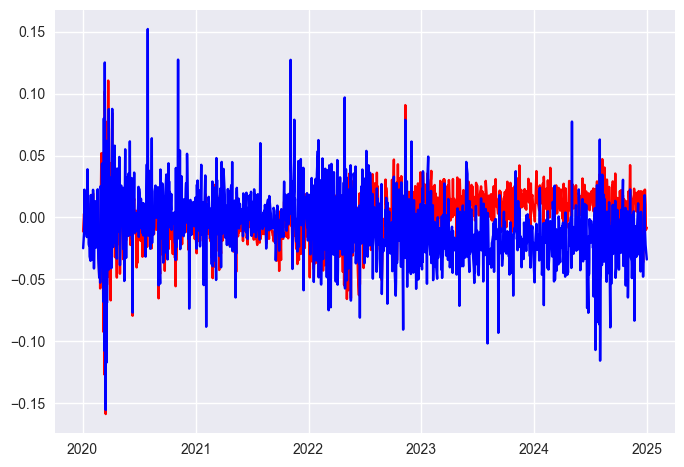

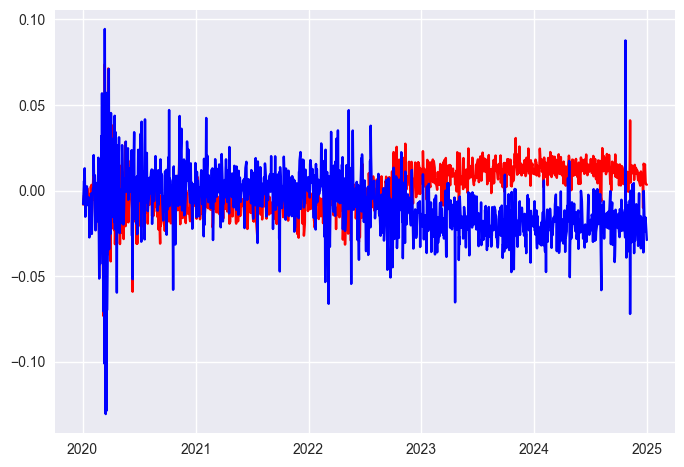

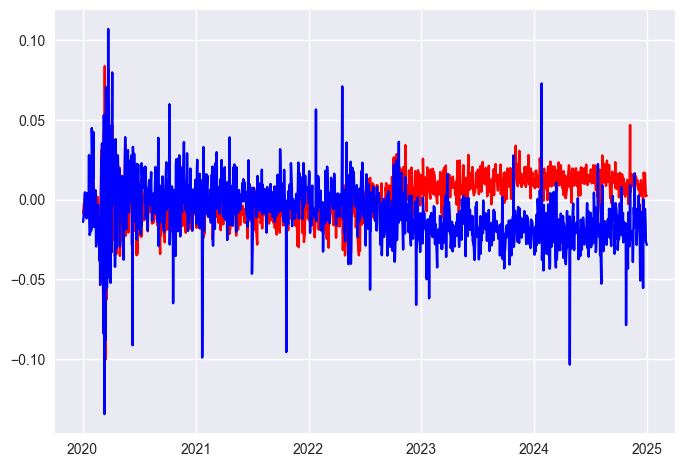

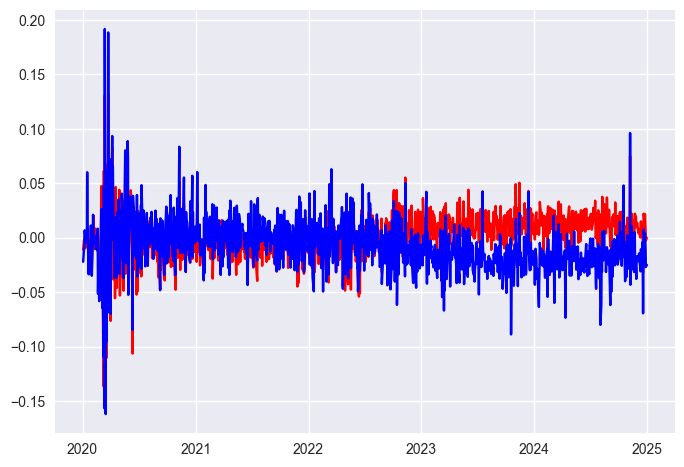

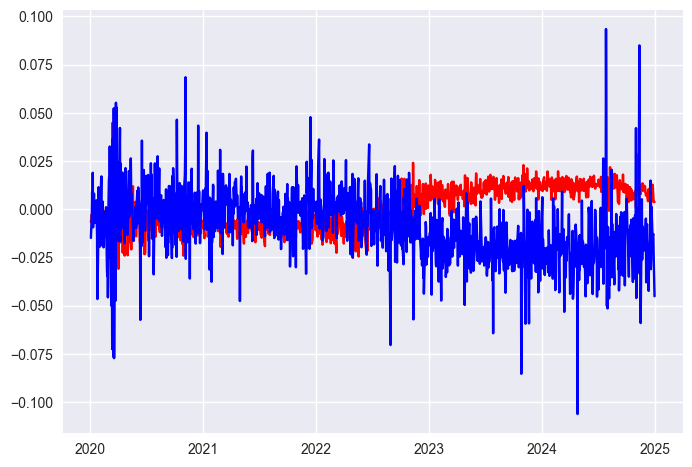

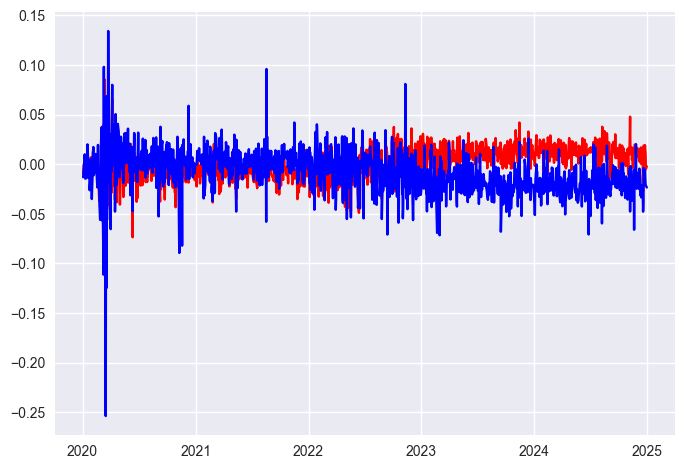

In [79]:
#Visualisation of both
for stock in tickers:
    plt.plot(reconstructed_returns[stock], color='red')
    plt.plot(data[stock],color='blue')
    f = plt.Figure()
    f.set_figwidth(10)
    f.set_figheight(10)
    plt.show()

In [80]:
class MVOOptimizer:
    """Class to implement Mean-Variance Optimization (MVO)"""

    def __init__(self, returns_data, risk_free_rate=0.02):
        self.returns = returns_data
        self.risk_free_rate = risk_free_rate
        self.mean_returns = None
        self.cov_matrix = None
        self.efficient_frontier = None
        self.optimal_weights = None

    def calculate_portfolio_metrics(self, weights):
        """Calculate portfolio return and risk"""
        portfolio_return = np.sum(self.mean_returns * weights) * 252
        portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix * 252, weights)))
        return portfolio_return, portfolio_risk

    def negative_sharpe_ratio(self, weights):
        """Calculate negative Sharpe ratio for optimization"""
        p_return, p_risk = self.calculate_portfolio_metrics(weights)
        return -(p_return - self.risk_free_rate) / p_risk

    def calculate_efficient_frontier(self, num_portfolios=100):
        """Calculate efficient frontier"""
        self.mean_returns = self.returns.mean()
        self.cov_matrix = self.returns.cov()

        num_assets = len(self.mean_returns)

        # Generate target returns
        min_ret = self.mean_returns.min() * 252
        max_ret = self.mean_returns.max() * 252
        target_returns = np.linspace(min_ret, max_ret, num_portfolios)

        efficient_portfolios = []

        for target in target_returns:
            # Constraints
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},  # Weights sum to 1
                {'type': 'eq', 'fun': lambda x: np.sum(self.mean_returns * x) * 252 - target}  # Target return
            ]

            # Bounds (no short selling)
            bounds = tuple((0, 1) for _ in range(num_assets))

            # Initial guess
            x0 = np.array([1/num_assets] * num_assets)

            # Minimize portfolio variance
            def portfolio_variance(weights):
                return np.dot(weights.T, np.dot(self.cov_matrix * 252, weights))

            result = minimize(portfolio_variance, x0, method='SLSQP',
                            bounds=bounds, constraints=constraints)

            if result.success:
                weights = result.x
                p_return, p_risk = self.calculate_portfolio_metrics(weights)
                efficient_portfolios.append([p_risk, p_return, weights])

        self.efficient_frontier = pd.DataFrame(efficient_portfolios,
                                            columns=['Risk', 'Return', 'Weights'])

    def find_optimal_portfolio(self):
        """Find portfolio with maximum Sharpe ratio"""
        if self.mean_returns is None:
            self.mean_returns = self.returns.mean()
            self.cov_matrix = self.returns.cov()

        num_assets = len(self.mean_returns)

        # Constraints and bounds
        constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
        bounds = tuple((0, 1) for _ in range(num_assets))
        x0 = np.array([1/num_assets] * num_assets)

        # Optimize for maximum Sharpe ratio
        result = minimize(self.negative_sharpe_ratio, x0, method='SLSQP',
                         bounds=bounds, constraints=constraints)

        if result.success:
            self.optimal_weights = result.x
            optimal_return, optimal_risk = self.calculate_portfolio_metrics(self.optimal_weights)
            optimal_sharpe = (optimal_return - self.risk_free_rate) / optimal_risk

            return {
                'weights': self.optimal_weights,
                'return': optimal_return,
                'risk': optimal_risk,
                'sharpe_ratio': optimal_sharpe
            }
        else:
            return None

    def plot_efficient_frontier(self):
        """Plot efficient frontier and optimal portfolio"""
        if self.efficient_frontier is None:
            self.calculate_efficient_frontier()

        optimal_portfolio = self.find_optimal_portfolio()

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('Mean-Variance Optimization (MVO) Analysis', fontsize=16, fontweight='bold')

        # Plot 1: Efficient Frontier
        axes[0].plot(self.efficient_frontier['Risk'], self.efficient_frontier['Return'],
                    'b-', linewidth=2, label='Efficient Frontier')

        # Plot individual assets
        for asset in self.returns.columns:
            asset_return = self.mean_returns[asset] * 252
            asset_risk = self.returns[asset].std() * np.sqrt(252)
            axes[0].scatter(asset_risk, asset_return, s=100, label=asset)

        # Plot optimal portfolio
        if optimal_portfolio:
            axes[0].scatter(optimal_portfolio['risk'], optimal_portfolio['return'],
                          s=200, color='red', marker='*', label='Optimal Portfolio')

        axes[0].set_xlabel('Risk (Standard Deviation)')
        axes[0].set_ylabel('Expected Return')
        axes[0].set_title('Efficient Frontier')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot 2: Optimal Portfolio Weights
        if optimal_portfolio:
            weights_df = pd.DataFrame({
                'Asset': self.returns.columns,
                'Weight': optimal_portfolio['weights']
            })

            axes[1].pie(weights_df['Weight'], labels=weights_df['Asset'], autopct='%1.1f%%')
            axes[1].set_title('Optimal Portfolio Weights')

        plt.tight_layout()
        plt.show()

        return optimal_portfolio

In [ ]:
def main_example():
    """Main function demonstrating CAPM and MVO with real data"""

    print("=" * 60)
    print("MEAN-VARIANCE OPTIMIZATION ANALYSIS")
    print("=" * 60)

    # Download sample data (last 2 years)
    end_date = enddate
    start_date = startdate

    # Stock symbols for analysis
    stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "TSLA", "LLY", "JPM",
    "V", "UNH", "XOM", "MA", "AVGO", "JNJ", "WMT", "PG", "HD", "MRK",
    "COST", "ADBE", "ORCL", "PEP", "CVX", "ABBV", "BAC", "CRM", "TMO", "NFLX",
    "KO", "ACN", "ABT", "LIN", "INTC", "NKE", "MCD", "AMD", "DHR", "WFC",
    "TXN", "AMGN", "NEE", "UPS", "QCOM", "PM", "IBM", "MS", "BMY", "LOW"
    ]

    market_symbol = '^GSPC'  # S&P 500 as market proxy

    print(f"Downloading data for: {', '.join(stocks)}")
    print(f"Market proxy: S&P 500 ({market_symbol})")
    print(f"Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print()

    # Download data
    try:
        stock_data = yf.download(stocks, start=start_date, end=end_date,auto_adjust=False)['Adj Close']
        market_data = yf.download(market_symbol, start=start_date, end=end_date,auto_adjust=False)['Adj Close']
    except Exception as e:
        print(f"Error downloading data: {e}")
        # Use synthetic data as fallback
        print("Using synthetic data for demonstration...")
        np.random.seed(42)
        dates = pd.date_range(start=start_date, end=end_date, freq='D')
        stock_data = pd.DataFrame(np.random.randn(len(dates), len(stocks)).cumsum(axis=0) + 100,
                                 index=dates, columns=stocks)
        market_data = pd.Series(np.random.randn(len(dates)).cumsum() + 100, index=dates)


    # MVO Analysis
    print("\n" + "="*40)
    print("MEAN-VARIANCE OPTIMIZATION")
    print("="*40)
    
    
    returns_data = stock_data.pct_change().dropna()
    mvo = MVOOptimizer(returns_data, risk_free_rate=0.02)

    # Find optimal portfolio
    optimal_portfolio = mvo.find_optimal_portfolio()

    if optimal_portfolio:
        print("\nOptimal Portfolio (Maximum Sharpe Ratio):")
        print(f"Expected Return: {optimal_portfolio['return']:.4f} ({optimal_portfolio['return']*100:.2f}%)")
        print(f"Risk (Std Dev): {optimal_portfolio['risk']:.4f} ({optimal_portfolio['risk']*100:.2f}%)")
        print(f"Sharpe Ratio: {optimal_portfolio['sharpe_ratio']:.4f}")

        print("\nOptimal Weights:")
        for i, stock in enumerate(stocks):
            weight = optimal_portfolio['weights'][i]
            print(f"- {stock}: {weight:.4f} ({weight*100:.2f}%)")

    # Plot efficient frontier
    mvo.plot_efficient_frontier()

    # Additional Analysis: Risk-Return Comparison
    print("\n" + "="*40)
    print("INDIVIDUAL ASSET ANALYSIS")
    print("="*40)

    individual_metrics = []
    for stock in stocks:
        stock_return = returns_data[stock].mean() * 252
        stock_risk = returns_data[stock].std() * np.sqrt(252)
        stock_sharpe = (stock_return - 0.02) / stock_risk
        individual_metrics.append([stock, stock_return, stock_risk, stock_sharpe])

    metrics_df = pd.DataFrame(individual_metrics,
                             columns=['Asset', 'Return', 'Risk', 'Sharpe_Ratio'])
    print(metrics_df.round(4))

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

[**********            20%                       ]  10 of 50 completed

MEAN-VARIANCE OPTIMIZATION ANALYSIS
Market proxy: S&P 500 (^GSPC)
Period: 2020-01-02 to 2024-12-31



[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  1 of 1 completed



MEAN-VARIANCE OPTIMIZATION
Ticker          AAPL      ABBV       ABT       ACN      ADBE       AMD  \
Date                                                                     
2020-01-03 -0.009722 -0.009492 -0.012191 -0.001665 -0.007834 -0.010183   
2020-01-06  0.007969  0.007892  0.005239 -0.006530  0.005726 -0.004321   
2020-01-07 -0.004703 -0.005705 -0.005560 -0.021590 -0.000959 -0.002893   
2020-01-08  0.016086  0.007087  0.004077  0.001962  0.013438 -0.008705   
2020-01-09  0.021241  0.007707  0.002668  0.008907  0.007636  0.023834   
...              ...       ...       ...       ...       ...       ...   
2024-12-23  0.003065  0.016004  0.000700 -0.020744 -0.000962  0.045214   
2024-12-24  0.011478  0.009025  0.003937  0.007972  0.002686  0.013563   
2024-12-26  0.003176 -0.004444  0.004444 -0.003318  0.004956 -0.009740   
2024-12-27 -0.013242 -0.006641 -0.002429 -0.011792 -0.008175  0.001040   
2024-12-30 -0.013263 -0.010168 -0.019045 -0.010360 -0.001523 -0.021967   

Ticker   

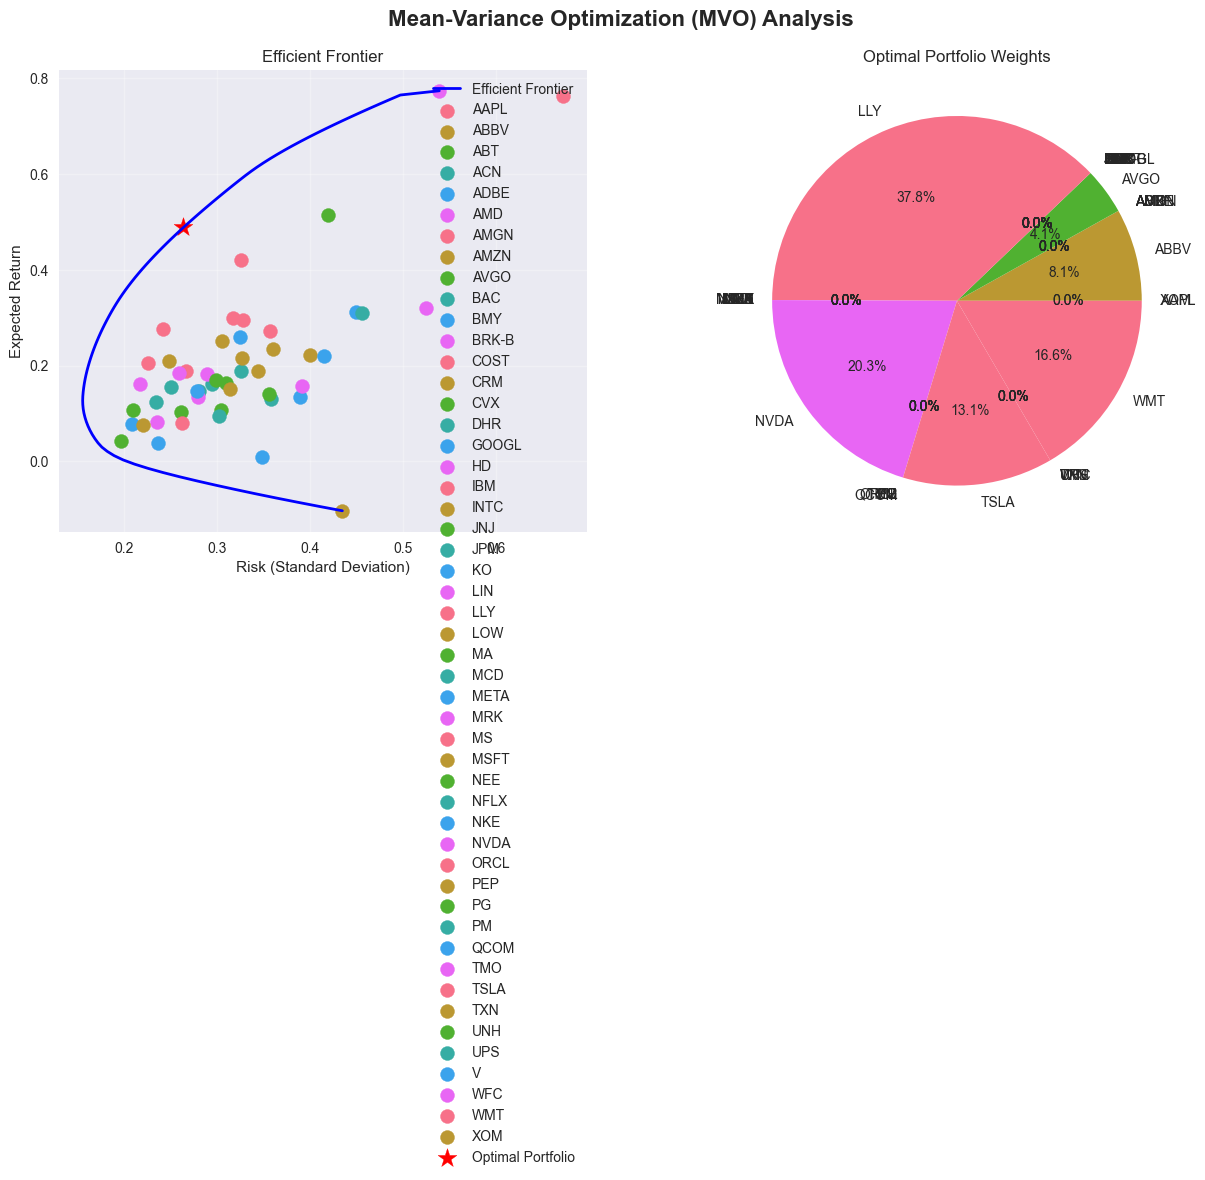


INDIVIDUAL ASSET ANALYSIS
    Asset  Return    Risk  Sharpe_Ratio
0    AAPL  0.2995  0.3169        0.8821
1    MSFT  0.2507  0.3051        0.7562
2   GOOGL  0.2598  0.3251        0.7378
3    AMZN  0.2346  0.3598        0.5964
4    NVDA  0.7738  0.5389        1.3989
5    META  0.3109  0.4492        0.6476
6   BRK-B  0.1607  0.2175        0.6469
7    TSLA  0.7625  0.6719        1.1050
8     LLY  0.4199  0.3258        1.2275
9     JPM  0.1878  0.3254        0.5155
10      V  0.1464  0.2790        0.4530
11    UNH  0.1703  0.2990        0.5027
12    XOM  0.1880  0.3439        0.4886
13     MA  0.1637  0.3099        0.4636
14   AVGO  0.5149  0.4190        1.1812
15    JNJ  0.0434  0.1966        0.1192
16    WMT  0.2063  0.2258        0.8252
17     PG  0.1075  0.2093        0.4178
18     HD  0.1814  0.2888        0.5589
19    MRK  0.0812  0.2353        0.2602
20   COST  0.2773  0.2415        1.0655
21   ADBE  0.1340  0.3889        0.2931
22   ORCL  0.2954  0.3283        0.8390
23    PEP  0.

In [86]:
if __name__ == "__main__":
    main_example()

In [91]:
def main_example_2():
    """Main function demonstrating CAPM and MVO with real data"""

    print("=" * 60)
    print("MEAN-VARIANCE OPTIMIZATION ANALYSIS")
    print("=" * 60)

    
    


    # MVO Analysis
    print("\n" + "="*40)
    print("HISTORICAL RETURNS AVERAGE")
    print("="*40)

    stocks = tickers
    risk_free = risk_free_daily.mean()
    mvo = MVOOptimizer(reconstructed_returns, risk_free_rate=risk_free)

    # Find optimal portfolio
    optimal_portfolio = mvo.find_optimal_portfolio()

    if optimal_portfolio:
        print("\nOptimal Portfolio (Maximum Sharpe Ratio):")
        print(f"Expected Return: {optimal_portfolio['return']:.4f} ({optimal_portfolio['return']*100:.2f}%)")
        print(f"Risk (Std Dev): {optimal_portfolio['risk']:.4f} ({optimal_portfolio['risk']*100:.2f}%)")
        print(f"Sharpe Ratio: {optimal_portfolio['sharpe_ratio']:.4f}")

        print("\nOptimal Weights:")
        for i, stock in enumerate(stocks):
            weight = optimal_portfolio['weights'][i]
            print(f"- {stock}: {weight:.4f} ({weight*100:.2f}%)")

    # Plot efficient frontier
    mvo.plot_efficient_frontier()

    # Additional Analysis: Risk-Return Comparison
    print("\n" + "="*40)
    print("INDIVIDUAL ASSET ANALYSIS")
    print("="*40)

    individual_metrics = []
    for stock in stocks:
        stock_return = reconstructed_returns[stock].mean() * 252
        stock_risk = reconstructed_returns[stock].std() * np.sqrt(252)
        stock_sharpe = (stock_return - risk_free) / stock_risk
        individual_metrics.append([stock, stock_return, stock_risk, stock_sharpe])

    metrics_df = pd.DataFrame(individual_metrics,
                             columns=['Asset', 'Return', 'Risk', 'Sharpe_Ratio'])
    print(metrics_df.round(4))

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

MEAN-VARIANCE OPTIMIZATION ANALYSIS

HISTORICAL RETURNS AVERAGE

Optimal Portfolio (Maximum Sharpe Ratio):
Expected Return: 0.4881 (48.81%)
Risk (Std Dev): 0.2379 (23.79%)
Sharpe Ratio: 2.0128

Optimal Weights:
- AAPL: 0.0000 (0.00%)
- MSFT: 0.0000 (0.00%)
- GOOGL: 0.0000 (0.00%)
- AMZN: 0.0000 (0.00%)
- NVDA: 0.0000 (0.00%)
- META: 0.0000 (0.00%)
- BRK-B: 0.0000 (0.00%)
- TSLA: 0.1992 (19.92%)
- LLY: 0.8008 (80.08%)
- JPM: 0.0000 (0.00%)
- V: 0.0000 (0.00%)
- UNH: 0.0000 (0.00%)
- XOM: 0.0000 (0.00%)
- MA: 0.0000 (0.00%)
- AVGO: 0.0000 (0.00%)
- JNJ: 0.0000 (0.00%)
- WMT: 0.0000 (0.00%)
- PG: 0.0000 (0.00%)
- HD: 0.0000 (0.00%)
- MRK: 0.0000 (0.00%)
- COST: 0.0000 (0.00%)
- ADBE: 0.0000 (0.00%)
- ORCL: 0.0000 (0.00%)
- PEP: 0.0000 (0.00%)
- CVX: 0.0000 (0.00%)
- ABBV: 0.0000 (0.00%)
- BAC: 0.0000 (0.00%)
- CRM: 0.0000 (0.00%)
- TMO: 0.0000 (0.00%)
- NFLX: 0.0000 (0.00%)
- KO: 0.0000 (0.00%)
- ACN: 0.0000 (0.00%)
- ABT: 0.0000 (0.00%)
- LIN: 0.0000 (0.00%)
- INTC: 0.0000 (0.00%)
- NKE:

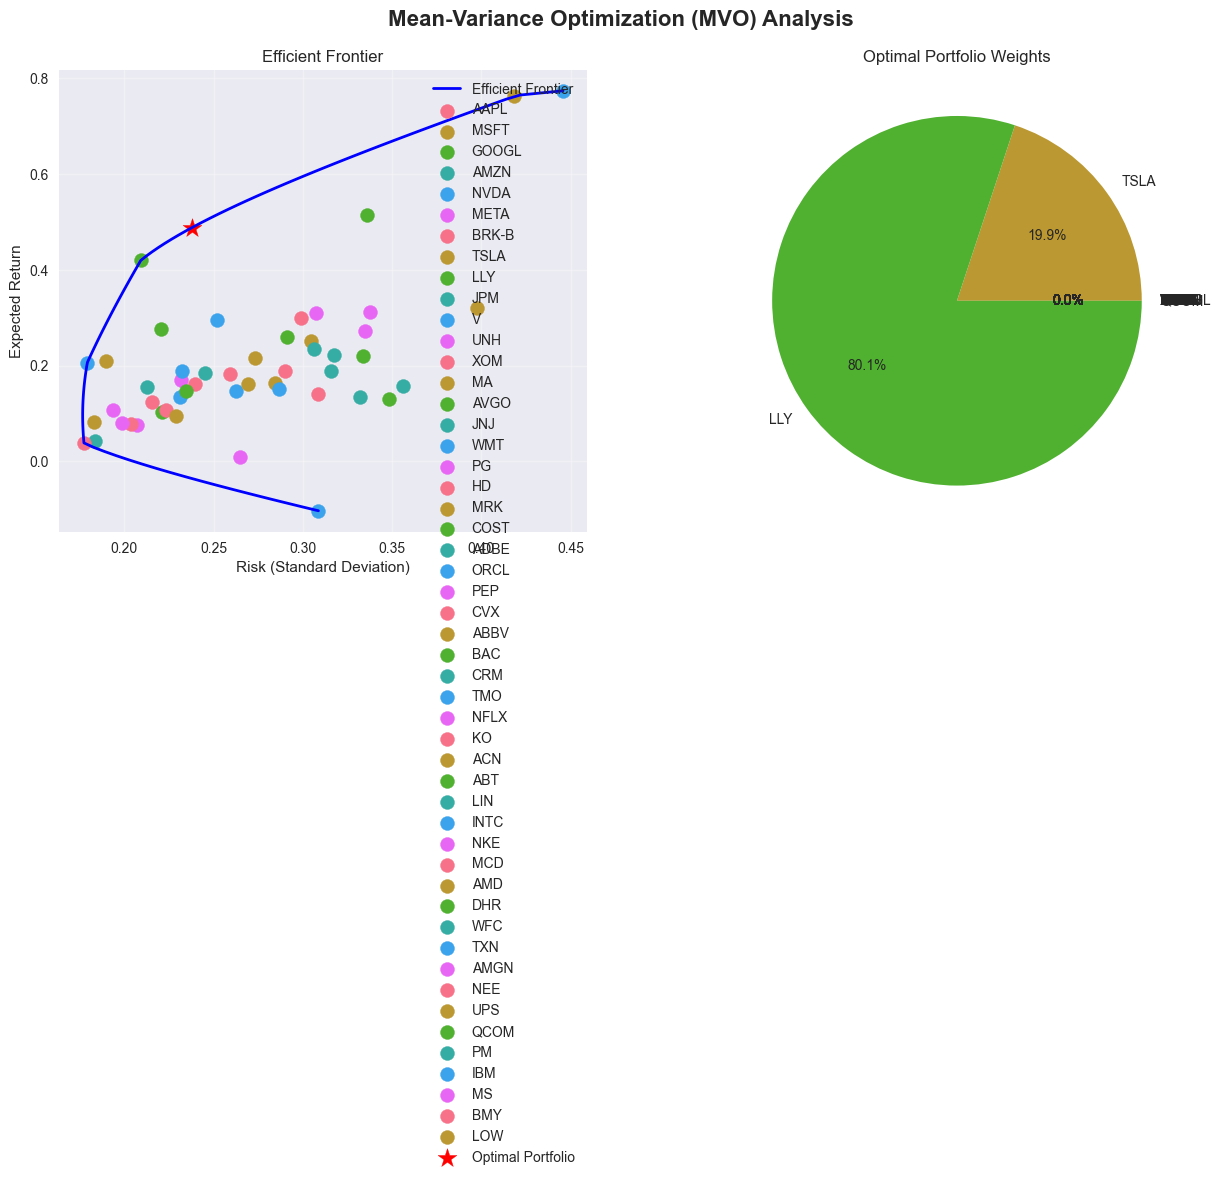


INDIVIDUAL ASSET ANALYSIS
    Asset  Return    Risk  Sharpe_Ratio
0    AAPL  0.2995  0.2992        0.9702
1    MSFT  0.2507  0.3044        0.7930
2   GOOGL  0.2598  0.2909        0.8614
3    AMZN  0.2346  0.3062        0.7359
4    NVDA  0.7738  0.4458        1.7151
5    META  0.3109  0.3376        0.8933
6   BRK-B  0.1607  0.2398        0.6315
7    TSLA  0.7625  0.4186        1.7994
8     LLY  0.4199  0.2093        1.9622
9     JPM  0.1878  0.3155        0.5657
10      V  0.1464  0.2628        0.5217
11    UNH  0.1703  0.2320        0.6941
12    XOM  0.1880  0.2900        0.6163
13     MA  0.1637  0.2844        0.5430
14   AVGO  0.5149  0.3361        1.5043
15    JNJ  0.0434  0.1838        0.1859
16    WMT  0.2063  0.1793        1.0992
17     PG  0.1075  0.1935        0.5073
18     HD  0.1814  0.2591        0.6643
19    MRK  0.0812  0.1831        0.3929
20   COST  0.2773  0.2204        1.2165
21   ADBE  0.1340  0.3319        0.3758
22   ORCL  0.2954  0.2519        1.1360
23    PEP  0.

In [92]:
if __name__ == "__main__":
    main_example_2()